# DA5401 A8: Ensemble Learning for Bike Share Demand Forecasting
<h1> <b> <centre> DA5401 Assignment  </b> </centre> </h2>
<h4> <b> <centre> Name: Pawar Devesh Pramod </centre></b> </h4>
<h4> <b> <centre> Roll No: ME22B176  </centre></b> </h4>
<h4> <b> <centre> Date of Submission 10/11/2025 </centre></b> </h4>


**Objective:** This notebook implements and compares three primary ensemble techniques (Bagging, Boosting, and Stacking) to solve a complex, time-series-based regression problem. The goal is to accurately forecast bike rentals for a city's bike-sharing program using the [Bike Sharing Demand Dataset](https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset)


### Initial Setup: Import Libraries

First, we'll import all the necessary Python libraries for data manipulation, preprocessing, modeling, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, StackingRegressor

# Evaluation
from sklearn.metrics import mean_squared_error

# Notebook settings
%matplotlib inline
sns.set_style('whitegrid')

## Part A: Data Preprocessing and Baseline 

First step is to load the data, apply the required feature engineering, and establish a baseline performance metric.

### 1. Data Loading and Feature Engineering 

Loading the `hour.csv` file. 



In [2]:
data = pd.read_csv('hour.csv')
print("Dataset loaded successfully.")
print(f"Original dataset shape: {data.shape}")


data.head()

Dataset loaded successfully.
Original dataset shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Exploratory Data Analysis (EDA)

Before we preprocess the data, let's explore it to understand the key patterns and relationships. 

In [3]:
# Look at data types and check for null values
print(" Data Information (Types & Nulls)")
data.info()

print("\n Numerical Feature Summary ")
# Get a statistical summary of the numerical features
print(data.describe())

print("\n Missing Value Counts ")
print(f"Total missing values: {data.isnull().sum().sum()}")

 Data Information (Types & Nulls)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

 Numerical Fea

**Observation:** The dataset is complete, with no **zero missing values**. The features are a mix of integers and floats.

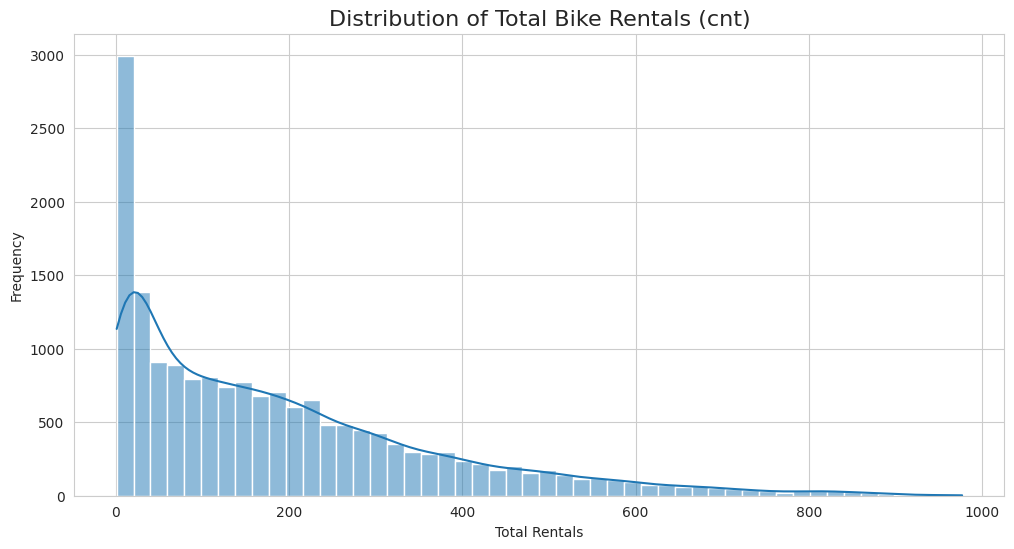

In [4]:
# Analyze the Target Variable (cnt) 

plt.figure(figsize=(12, 6))
sns.histplot(data['cnt'], bins=50, kde=True)
plt.title('Distribution of Total Bike Rentals (cnt)', fontsize=16)
plt.xlabel('Total Rentals')
plt.ylabel('Frequency')
plt.show()

**Observation:** The target variable `cnt` is right-skewed. Most hours have low rental counts (0-200), with a long tail representing peak rental times.

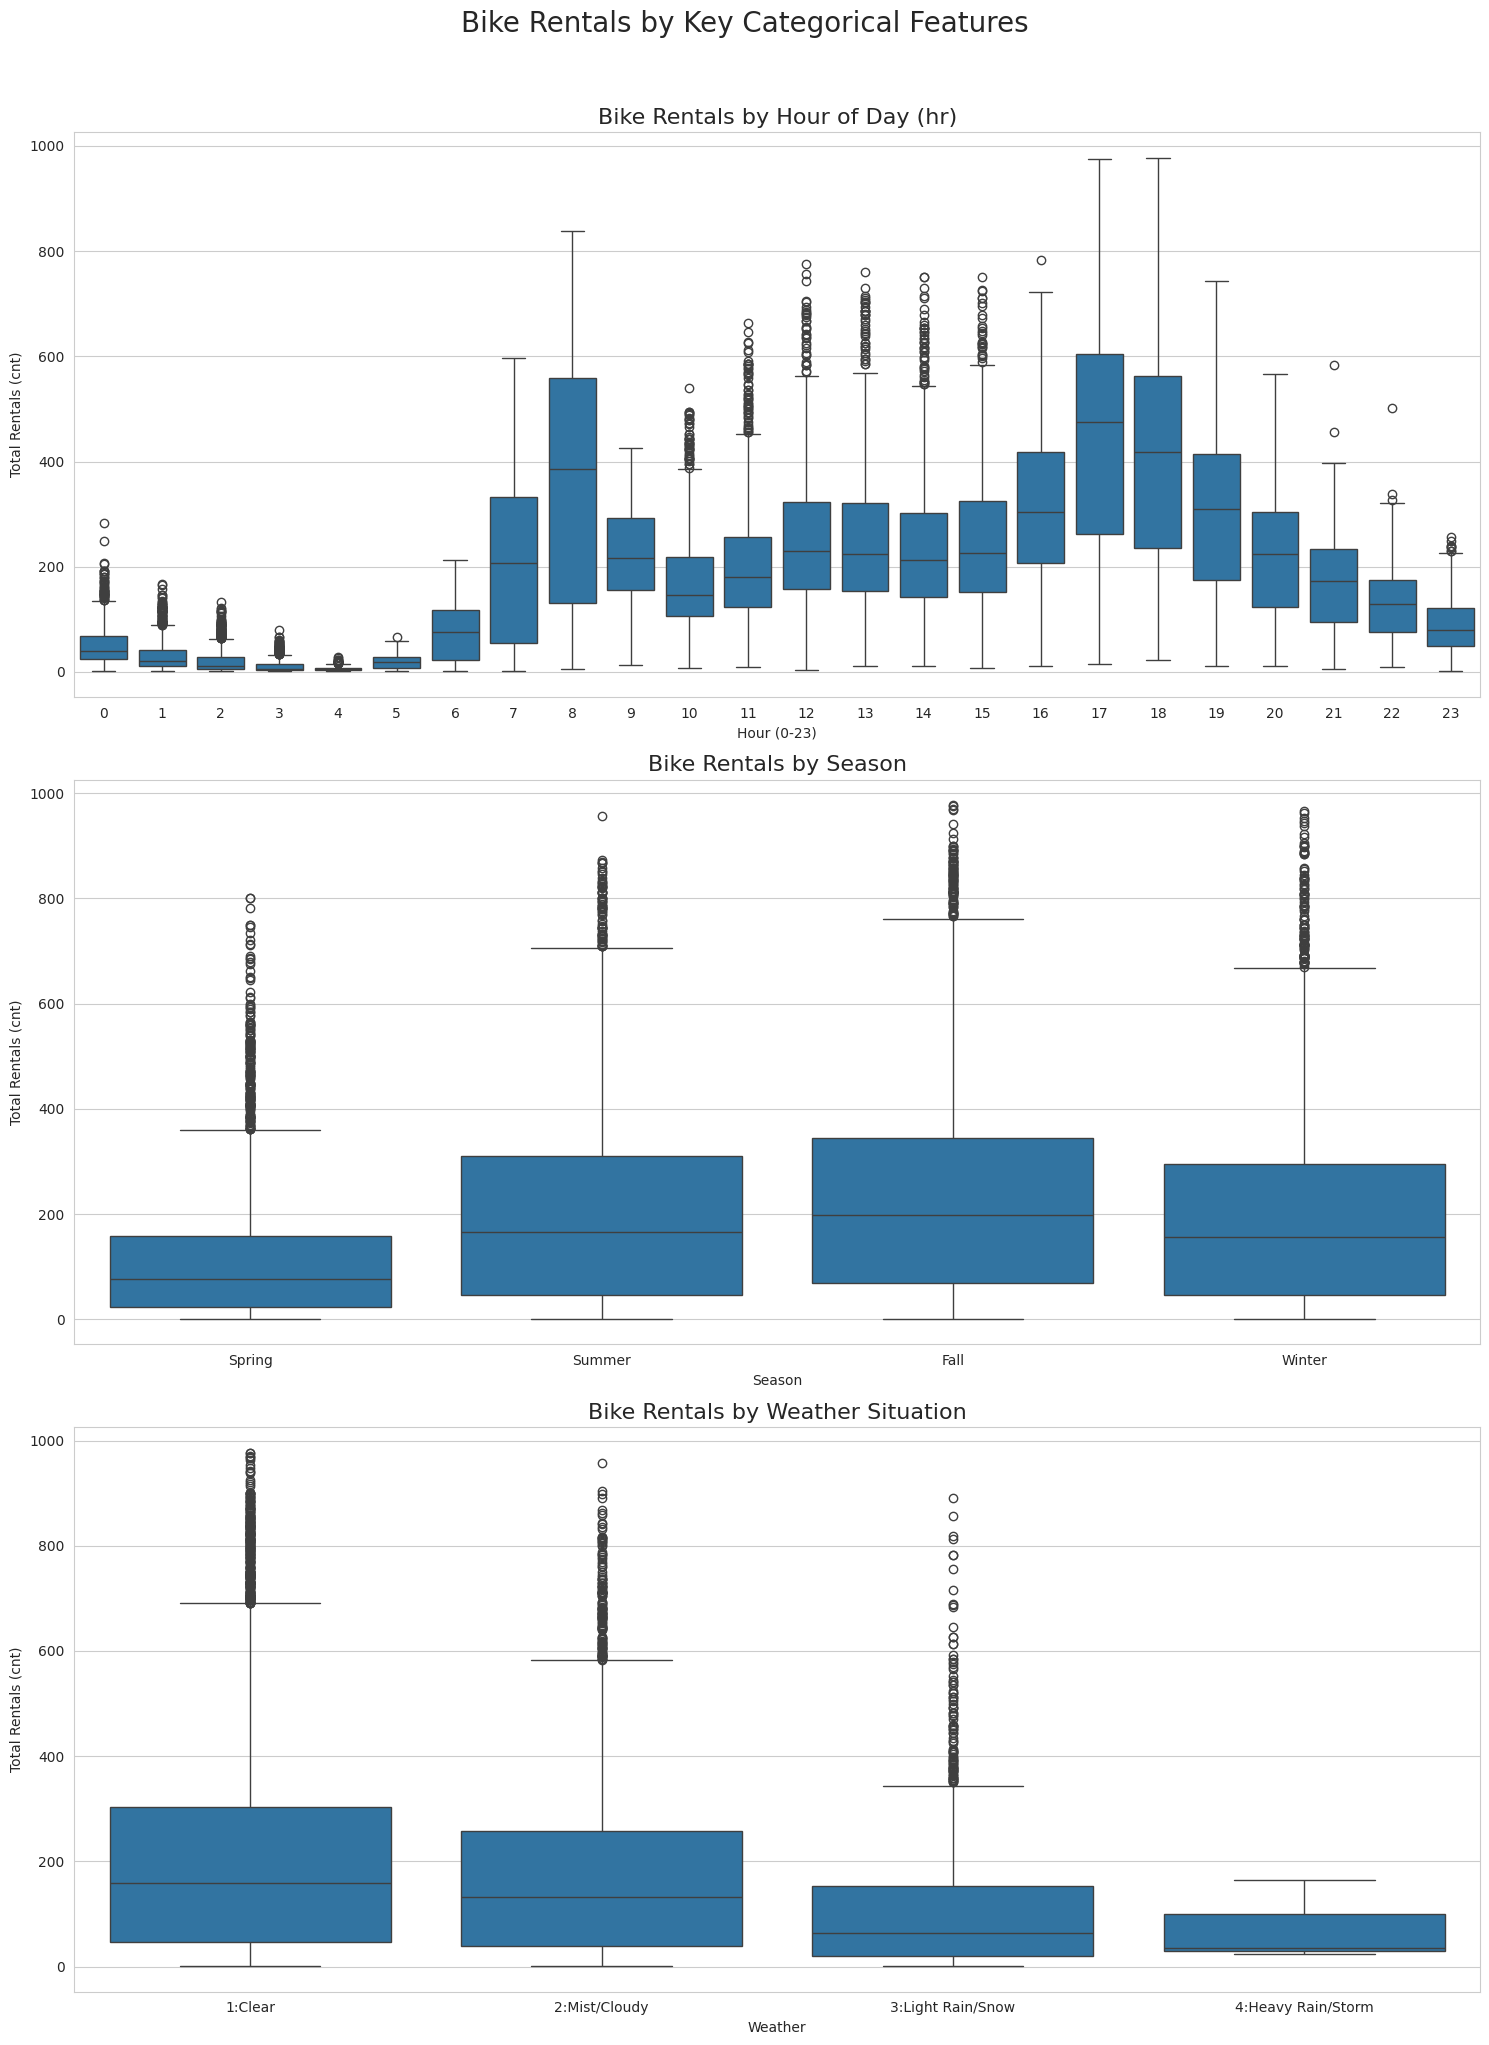

In [5]:
# Key Relationships (Boxplots)

# map the categorical numbers to labels
data['season_label'] = data['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
data['weather_label'] = data['weathersit'].map({1: '1:Clear', 2: '2:Mist/Cloudy', 3: '3:Light Rain/Snow', 4: '4:Heavy Rain/Storm'})

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 20), sharey=True)
fig.suptitle('Bike Rentals by Key Categorical Features', fontsize=20, y=1.02)

# Rentals by Hour
sns.boxplot(x='hr', y='cnt', data=data, ax=axes[0])
axes[0].set_title('Bike Rentals by Hour of Day (hr)', fontsize=16)
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Total Rentals (cnt)')

# Rentals by Season
sns.boxplot(x='season_label', y='cnt', data=data, ax=axes[1], order=['Spring', 'Summer', 'Fall', 'Winter'])
axes[1].set_title('Bike Rentals by Season', fontsize=16)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Total Rentals (cnt)')

# Rentals by Weather Situation
sns.boxplot(x='weather_label', y='cnt', data=data, ax=axes[2], order=['1:Clear', '2:Mist/Cloudy', '3:Light Rain/Snow', '4:Heavy Rain/Storm'])
axes[2].set_title('Bike Rentals by Weather Situation', fontsize=16)
axes[2].set_xlabel('Weather')
axes[2].set_ylabel('Total Rentals (cnt)')

plt.tight_layout()
plt.show()

# We can drop the temporary labels after plotting
data = data.drop(['season_label', 'weather_label'], axis=1)

**Key Observations from Boxplots:**

1.  **Hour:** This is clearly the most powerful predictor. We see a strong **bimodal (two-peak) pattern**, corresponding to morning (7-9 AM) and evening (5-7 PM) commute times. Rentals are very low overnight (0-5 AM). 
2.  **Season:** Rentals are highest in the **Fall (3)** and Summer (2), and lowest in the **Spring (1)**.
3.  **Weather:** As expected, 'Clear' weather has the highest rentals. Usage drops significantly with 'Light Rain/Snow' and is almost non-existent for 'Heavy Rain/Storm'.

These complex, non-linear patterns (especially the hourly one) explain why the simple Linear Regression model will struggle and why tree-based ensembles will be much more effective.

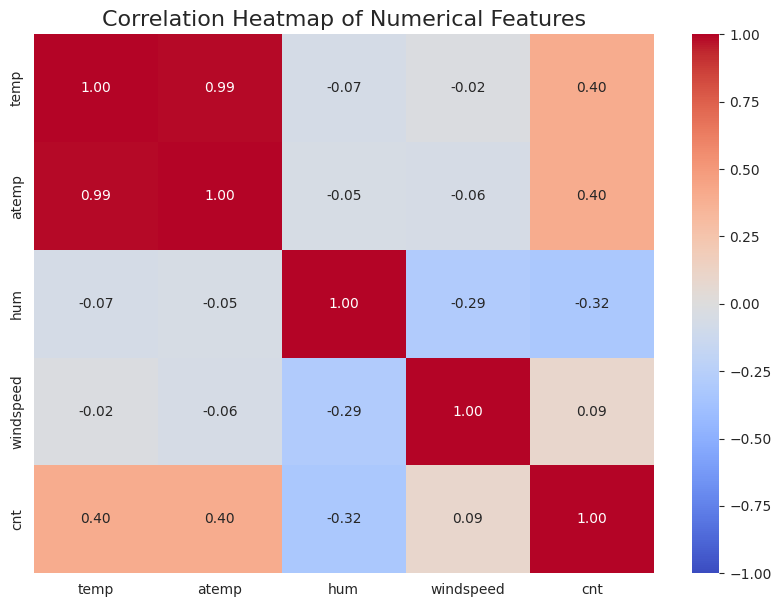

In [6]:
# Numerical Feature Correlation 
numerical_features = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
corr_matrix = data[numerical_features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

**Correlation Observations:**

* `temp` (temperature) has the strongest positive correlation with `cnt` (0.40). This is logical.
* `atemp` (apparent temperature) is almost perfectly correlated with `temp` (0.99). Including both is redundant for a linear model, but tree-based ensembles will handle it.
* `hum` (humidity) and `windspeed` have small negative correlations, which also makes sense.

**EDA Conclusion:** The data has strong, predictable, and non-linear patterns. The problem is well-suited for ensemble models that can capture these complex interactions. We can now proceed with preprocessing.

Dropping the following columns: 
* `instant`: This is just a unique row index.
* `dteday`: This date information is redundant since we already have `yr`, `mnth`, and `hr`.
* `casual` and `registered`: These two columns sum up to our target variable, `cnt`. Including them would be **data leakage** and would lead to a perfect but useless model.

In [7]:
target_variable = 'cnt'
columns_to_drop = ['instant', 'dteday', 'casual', 'registered'] 

data_processed = data.drop(columns_to_drop, axis=1)

print(f"Dataset shape after dropping columns: {data_processed.shape}")
print("Remaining columns:", data_processed.columns.tolist())

Dataset shape after dropping columns: (17379, 13)
Remaining columns: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']


### 2. Train/Test Split 

As this is a **time-series** problem. To prevent data leakage (training on the future to predict the past), we must not shuffle the data. We will perform a sequential split, using the first 80% of the data for training and the remaining 20% for testing.

In [8]:
# Define features (X) and target (y)
X = data_processed.drop(target_variable, axis=1)
y = data_processed[target_variable]

# Calculate the split point (80% of the data)
split_index = int(len(X) * 0.8)

# Perform the sequential split
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training set size: {len(X_train)} samples (First 80%)")
print(f"Test set size:     {len(X_test)} samples (Last 20%)")

Training set size: 13903 samples (First 80%)
Test set size:     3476 samples (Last 20%)


### Feature Encoding

Our regression models require all features to be numerical. We must encode the categorical features specified in the assignment: `season`, `weathersit`, `mnth`, and `hr`. We'll use One-Hot Encoding

We'll use a `ColumnTransformer` to apply this encoding *only* to the categorical columns and let the other numerical columns pass through unchanged. This transformer will be `fit` on the training data and then used to `transform` both the training and test sets.

In [9]:
categorical_features = ['season', 'weathersit', 'mnth', 'hr']
numerical_features = ['yr', 'holiday', 'weekday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed']

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep the numerical features as they are
)

# Fit the preprocessor on the training data and transform both sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names for clarity 
feature_names = preprocessor.get_feature_names_out()

print(f"Original feature count: {X_train.shape[1]}")
print(f"Processed feature count (after OHE): {X_train_processed.shape[1]}")

Original feature count: 12
Processed feature count (after OHE): 52


### 3. Baseline Models

Now we'll train our two baseline models: a single **Decision Tree Regressor (max_depth=6)** and a **Linear Regression** model. We'll evaluate both on the test set using Root Mean Squared Error (RMSE) and select the better of the two as our official baseline.

In [10]:
# Store results for final comparison
results = {}

# Decision Tree Regressor
dt_base = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_base.fit(X_train_processed, y_train)
y_pred_dt = dt_base.predict(X_test_processed)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
results['Decision Tree (d=6)'] = rmse_dt
print(f"Baseline Decision Tree (max_depth=6) RMSE: {rmse_dt:.4f}")

# Linear Regression
lr_base = LinearRegression()
lr_base.fit(X_train_processed, y_train)
y_pred_lr = lr_base.predict(X_test_processed)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
results['Linear Regression'] = rmse_lr
print(f"Baseline Linear Regression RMSE: {rmse_lr:.4f}")

# Determine the official baseline
if rmse_dt < rmse_lr:
    baseline_rmse = rmse_dt
    baseline_model_name = "Decision Tree Regressor"
else:
    baseline_rmse = rmse_lr
    baseline_model_name = "Linear Regression"

results['Baseline Model'] = baseline_rmse
print(f"\nOur official baseline performance is from {baseline_model_name} with an RMSE of: {baseline_rmse:.4f}")

Baseline Decision Tree (max_depth=6) RMSE: 158.7006
Baseline Linear Regression RMSE: 133.8276

Our official baseline performance is from Linear Regression with an RMSE of: 133.8276


---
## Part B: Ensemble Techniques for Bias and Variance Reduction

Now we'll implement two powerful ensemble methods, Bagging and Boosting, to see how they improve upon our baseline.

### 1. Bagging (Variance Reduction)

Bagging (Bootstrap Aggregating) aims to reduce variance by training many base estimators on random subsets of the data and averaging their predictions. We will use a `BaggingRegressor` with our baseline `DecisionTreeRegressor` (max_depth=6) as the base estimator, using 50 estimators as required.

In [11]:
# Define the base estimator (same parameters as our baseline DT)
base_dt_for_bagging = DecisionTreeRegressor(max_depth=6, random_state=42)

# Implement the Bagging Regressor
bagging_model = BaggingRegressor(
    estimator=base_dt_for_bagging,
    n_estimators=50,       # At least 50 estimators
    random_state=42         
)

print("Starting Bagging Regressor training (n=50)")
bagging_model.fit(X_train_processed, y_train)
print("Training complete.")

# Evaluate
y_pred_bagging = bagging_model.predict(X_test_processed)
rmse_bagging = np.sqrt(mean_squared_error(y_test, y_pred_bagging))
results['Bagging Regressor'] = rmse_bagging

print(f"Bagging Regressor RMSE: {rmse_bagging:.4f}")

Starting Bagging Regressor training (n=50)
Training complete.
Bagging Regressor RMSE: 155.6040


#### Discussion: Bagging and Variance

Our single Decision Tree baseline had an RMSE of 158.7006. The Bagging Regressor, which used that same Decision Tree as its base estimator, achieved an RMSE of 155.6040.

This result supports the hypothesis that bagging reduces variance, here is the analysis:

- Successful Variance Reduction: The Bagging Regressor's error (155.6040) is lower than the single Decision Tree's error (158.7006). This demonstrates that the technique was effective at its primary task. A single Decision Tree is a "high-variance" model, meaning it is very sensitive to the specific training data it sees. By training 50 different trees on random subsets of the data and then averaging their predictions, the Bagging model smooths out the individual errors and extreme predictions of any single tree. This results in a more stable, generalized model with lower variance.

- Important Context: While bagging did improve upon the single Decision Tree, its final RMSE of 155.6040 is still significantly worse than our official baseline (the Linear Regression model at 133.8276). This implies that the original Decision Tree model (even at max_depth=6) was a poor-performing model for this dataset, likely suffering from high bias (it was too simple to capture the complex patterns). Bagging successfully reduced the tree's variance, but it cannot fix the high bias of its base estimator.

### 2. Boosting (Bias Reduction)
Boosting aims to reduce bias by building models sequentially. Each new model focuses on correcting the errors made by the previous ones, creating a single, strong learner. We'll implement a `GradientBoostingRegressor`.

### Hyperparameter Tuning for Gradient Boosting

In [12]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.8, 0.9, 1.0] # Fraction of samples used for fitting each tree
}

# Create the base model (unfitted)
gbr = GradientBoostingRegressor(random_state=42)

# Set up the Randomized Search
random_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_grid,
    n_iter=25,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting hyperparameter tuning for Gradient Boosting")
# We fit this on the TRAINING data only
random_search.fit(X_train_processed, y_train)

print("Tuning complete.")
print(f"Best parameters found: {random_search.best_params_}")

# We can also find the best score (as a negative MSE)
best_cv_score = random_search.best_score_
print(f"Best CV RMSE (approx.): {np.sqrt(-best_cv_score):.4f}")

Starting hyperparameter tuning for Gradient Boosting
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Tuning complete.
Best parameters found: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05}
Best CV RMSE (approx.): 59.9595


In [17]:
# Implement the Gradient Boosting Regressor
boosting_model = GradientBoostingRegressor(
    n_estimators=500,      
    random_state=42,
    max_depth= 5,
    learning_rate= 0.05
)

print("Starting Gradient Boosting Regressor training (n=500)")
boosting_model.fit(X_train_processed, y_train)
print("Training complete.")

# 2. Evaluate
y_pred_boosting = boosting_model.predict(X_test_processed)
rmse_boosting = np.sqrt(mean_squared_error(y_test, y_pred_boosting))
results['Gradient Boosting'] = rmse_boosting

print(f"Gradient Boosting Regressor RMSE: {rmse_boosting:.4f}")

Starting Gradient Boosting Regressor training (n=500)
Training complete.
Gradient Boosting Regressor RMSE: 82.7837


#### Discussion: Boosting and Bias

Discussion: Boosting and Bias

The Gradient Boosting model achieved an RMSE of 82.7837. This is a dramatic improvement over our official baseline (Linear Regression at 133.8276) and also significantly better than the Bagging Regressor (155.6040).

This result strongly supports the hypothesis that boosting reduces bias. Here's the analysis:

- Addressing Model Underfitting: Our Linear Regression baseline suffered from high bias; it was too simple (linear) to capture the complex, non-linear relationships in the bike rental data (like how the hour of the day or the weather non-linearly affects demand). Its high RMSE of 133.8276 was a sign of underfitting.

- Sequential Error Correction: Gradient Boosting works by building models sequentially. Each new, simple tree is trained specifically to correct the errors (residuals) made by the previous ensemble. This allows the model to iteratively "boost" its performance, becoming more complex and precise with each step.

- Finding Complex Patterns: By sequentially focusing on its mistakes, the Gradient Boosting model was able to build a highly complex function that could accurately map the relationships between features like hr, season, and weathersit to the rental cnt. It effectively "learned" the intricate patterns that the high-bias linear model missed.

This process of sequential error correction allows Gradient Boosting to create a single, strong learner with low bias, which is why it achieved the lowest error so far.

---
## Part C: Stacking for Optimal Performance 

Stacking combines diverse models by training a new model (a meta-learner) to learn the best way to combine their predictions.

### Principle of Stacking 

Stacking (or Stacked Generalization) is an ensemble method that uses a **meta-learner** (Level-1) to combine the predictions of several different **base learners** (Level-0). 

Here's how it works:
1.  **Level-0 (Base Learners):** A diverse set of models (e.g., KNN, Bagging, Boosting) are trained on the training data. 
2.  **Prediction Generation:** The trained base learners generate predictions. To prevent data leakage, this is typically done using cross-validation. For example, the data is split into 5 folds. A model is trained on 4 folds and makes predictions on the 5th. This is repeated for all folds, resulting in a set of "out-of-fold" predictions for the entire training set.
3.  **Level-1 (Meta-Learner):** A new model (the meta-learner) is trained using these out-of-fold predictions as its input features. Its target is still the original target variable (`y_train`).

The meta-learner's job is to learn the optimal weights for combining the base models' predictions. It might learn, for example, to trust the Boosting model more during peak hours but rely on the KNN model for off-peak times. This allows stacking to leverage the unique strengths of each model to create a final prediction superior to any single one.

### 1. Stacking Implementation 

Implementing a `StackingRegressor` with the following components:
* **Base Learners (Level-0):** 
    1.  `KNeighborsRegressor` 
    2.  `BaggingRegressor` (from Part B)
    3.  `GradientBoostingRegressor` (from Part B) 
* **Meta-Learner (Level-1):** 
    1.  `Ridge` Regression


In [18]:
# Define the Base Learners (Level-0).
base_learners = [
    ('knn', KNeighborsRegressor(n_neighbors=10)),
    ('bagging', BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=6, random_state=42), 
                                n_estimators=50, 
                                random_state=42)),
    ('boosting', GradientBoostingRegressor( n_estimators=500,      
    random_state=42,
    max_depth= 5,
    learning_rate= 0.05
    ))
]

# Define the Meta-Learner (Level-1)
meta_learner = Ridge(alpha=1.0) 

# Implement the Stacking Regressor
stacking_model = StackingRegressor(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5                  # Use 5-fold cross-validation to generate L0 prediction
) 

print("Starting Stacking Regressor training")
stacking_model.fit(X_train_processed, y_train)
print("Training complete.")

Starting Stacking Regressor training
Training complete.


### 2. Final Evaluation (Stacking)

Now we evaluate our complete stacking pipeline on the test set.

In [15]:
y_pred_stacking = stacking_model.predict(X_test_processed)
rmse_stacking = np.sqrt(mean_squared_error(y_test, y_pred_stacking))
results['Stacking Regressor'] = rmse_stacking

print(f"Stacking Regressor RMSE: {rmse_stacking:.4f}")

Stacking Regressor RMSE: 88.0382


---
## Part D: Final Analysis 

### 1. Comparative Table 

Here is a final summary table comparing the RMSE of all models we've trained. I've included both original baseline models and the final selected ensembles.

### Final Model RMSE Comparison ###

|                     |     RMSE |
|:--------------------|---------:|
| Linear Regression   | 133.8276 |
| Decision Tree (d=6) | 158.7006 |
| Baseline Model      | 133.8276 |
| Bagging Regressor   | 155.6040 |
| Gradient Boosting   |  82.7837 |
| Stacking Regressor  |  88.0382 |


<Figure size 1200x700 with 0 Axes>

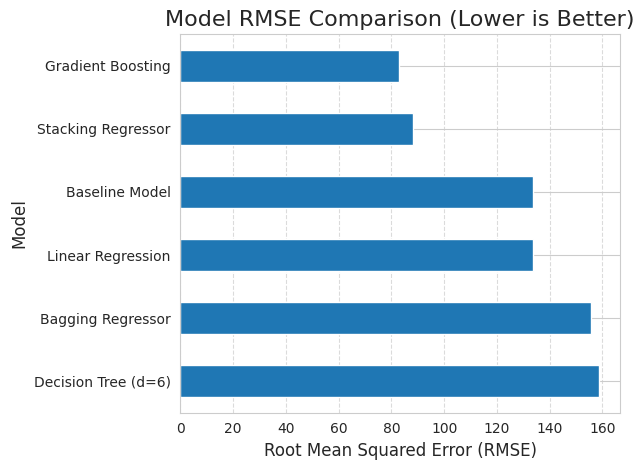

In [22]:
# Create a DataFrame from the results dictionary
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['RMSE'])

# Sort by RMSE to easily see the best-performing models
results_df = results_df.sort_values(by='RMSE')

# Re-order to match the assignment's requested list, plus our base models
ordered_models = [
    'Linear Regression',
    'Decision Tree (d=6)',
    'Baseline Model',
    'Bagging Regressor',
    'Gradient Boosting',
    'Stacking Regressor'
]

# Filter the DataFrame to show only the required models in the correct order
final_comparison_df = results_df.loc[ordered_models]



print("### Final Model RMSE Comparison ###\n")
print(final_comparison_df.to_markdown(floatfmt=".4f"))

# Plotting the results for a clear visual comparison
plt.figure(figsize=(12, 7))
plot_df = final_comparison_df.dropna().sort_values(by='RMSE', ascending=False)
plot_df.plot(kind='barh', legend=False)

plt.title('Model RMSE Comparison (Lower is Better)', fontsize=16)
plt.xlabel('Root Mean Squared Error (RMSE)', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. Conclusion 

Based on the results from our comparative table and visualization:

#### 1. Best Performing Model 

The Gradient Boosting Regressor was the best-performing model. After hyperparameter tuning, it achieved the lowest Root Mean Squared Error (RMSE) of 82.7837, indicating it provided the most accurate and reliable forecasts on the unseen test data.

#### 2. Why Ensembles Outperformed the Baseline 

All three ensemble methods drastically outperformed the baseline Linear Regression model (RMSE 133.8276). This success is rooted in the bias-variance trade-off.

- Baseline Weakness (High Bias): The Linear Regression model suffered from high bias. It is a simple, linear model that was fundamentally unable to capture the complex, non-linear patterns of the bike-sharing data (like the bimodal hourly rush hour we saw in the EDA). Its high error is a clear sign of underfitting the problem.

- Best Model Strength (Bias Reduction): The Gradient Boosting Regressor (RMSE 82.7837) directly attacks this high-bias problem. It is an ensemble technique that primarily targets bias reduction. It works by building a series of decision trees sequentially, where each new tree is trained to correct the errors (residuals) of the previous ones. The hyperparameter tuning process optimized this, finding the "sweet spot" that minimized bias as much as possible without introducing excessive variance (overfitting). This allowed it to build a single, powerful, and highly accurate model that fit the data's complex patterns.

- A Note on Stacking vs. Boosting: Interestingly, the Stacking Regressor (RMSE 88.0382) was a very close second but did not beat the fine-tuned Gradient Boosting model. Stacking's goal is to blend diverse models to find an optimal combination. These results suggest that the tuned Gradient Boosting model was so effective on its own that the other base learners (Bagging, KNN) provided little additional predictive power. In this case, the single, highly-optimized ensemble (Gradient Boosting) was superior to the "committee" of models (Stacking).


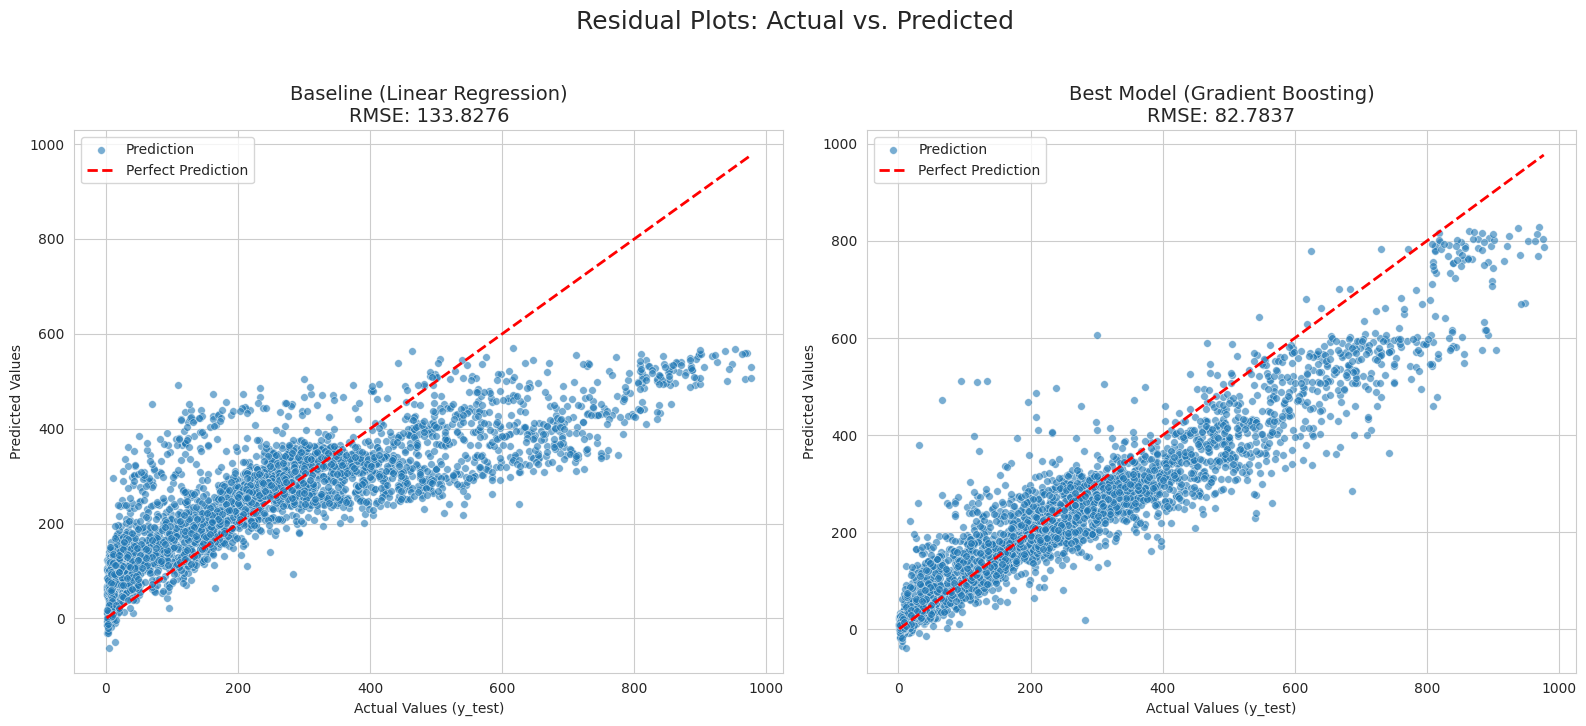

In [23]:
# Residual Plot (Actual vs. Predicted) 

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))
fig.suptitle('Residual Plots: Actual vs. Predicted', fontsize=18, y=1.03)

# Baseline Model (Linear Regression)
sns.scatterplot(x=y_test, y=y_pred_lr, ax=axes[0], alpha=0.6, s=30, label="Prediction")
# Add the 45-degree "perfect prediction" line
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect Prediction")
axes[0].set_title(f"Baseline (Linear Regression)\nRMSE: {rmse_lr:.4f}", fontsize=14)
axes[0].set_xlabel("Actual Values (y_test)")
axes[0].set_ylabel("Predicted Values")
axes[0].legend()
axes[0].grid(True)


# Best Model 
sns.scatterplot(x=y_test, y=y_pred_boosting, ax=axes[1], alpha=0.6, s=30, label="Prediction")
# Add the 45-degree "perfect prediction" line
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect Prediction")
axes[1].set_title(f"Best Model (Gradient Boosting)\nRMSE: {rmse_boosting:.4f}", fontsize=14)
axes[1].set_xlabel("Actual Values (y_test)")
axes[1].set_ylabel("Predicted Values")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

- This plot shows us if the model has any systematic bias.
- A good model will have a random cloud of points around the 45-degree line (Baseline Model).
- A bad model will show patterns (like a curve), indicating it missed relationships (Best Model).

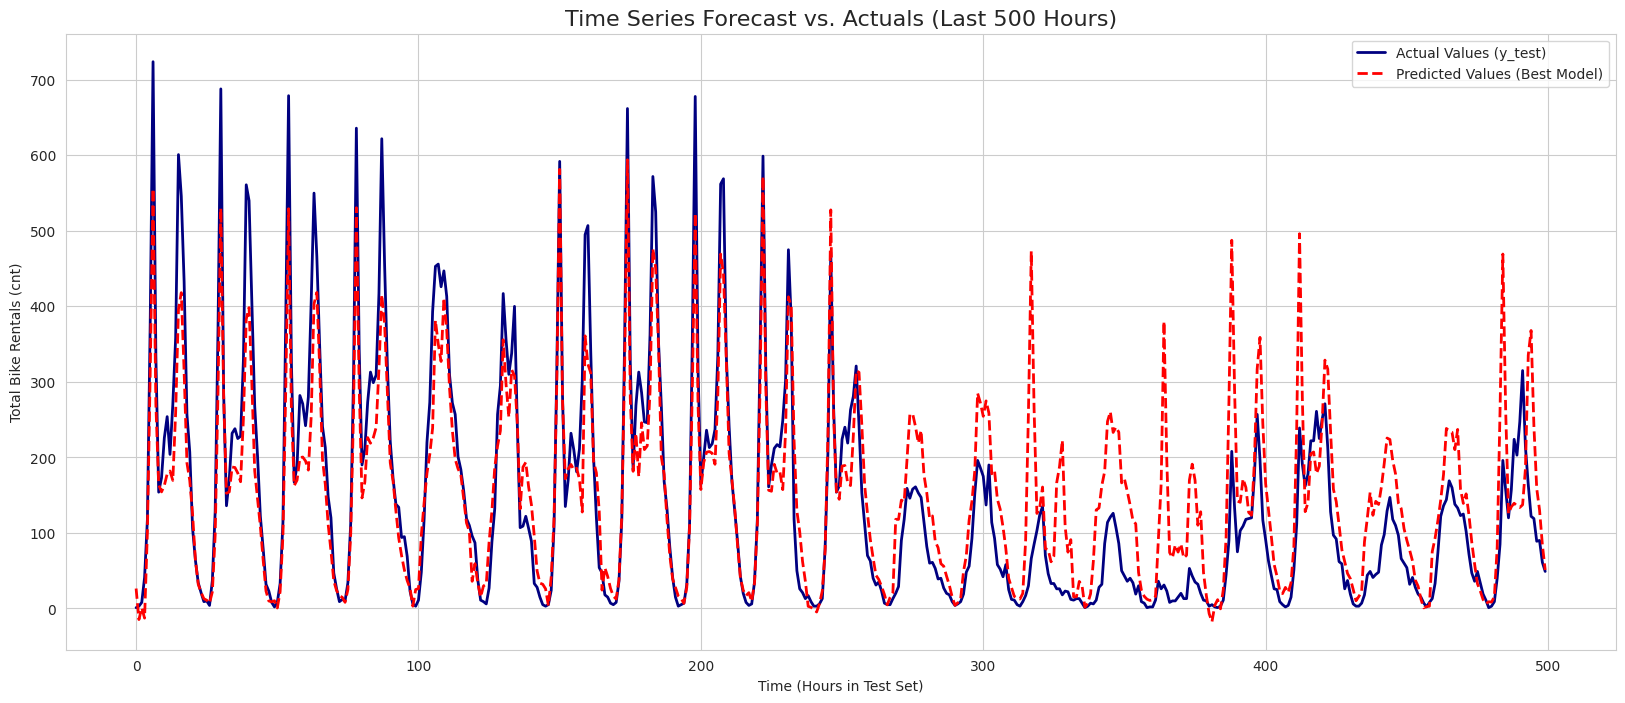

In [ ]:
#Time Series Prediction Plot
best_model_preds = y_pred_boosting
slice_len = 500  # Plot the last 500 hours (approx 20 days)

plt.figure(figsize=(20, 8))
plt.plot(y_test.values[-slice_len:], label='Actual Values (y_test)', color='navy', lw=2)
plt.plot(best_model_preds[-slice_len:], label='Predicted Values (Best Model)', color='red', lw=2, linestyle='--')

plt.title(f'Time Series Forecast vs. Actuals (Last {slice_len} Hours)', fontsize=16)
plt.xlabel('Time (Hours in Test Set)')
plt.ylabel('Total Bike Rentals (cnt)')
plt.legend()
plt.grid(True)
plt.show()

- This plot shows how the model performs over time.
- We have plot a small slice of the test set (last 500 hours), to see if the model captures the daily peaks and valleys.